# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Catherine Aprilia Harlina | 5054251012 |

# 1. Persiapan Dataset dan Eksplorasi Awal

In [131]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA
warnings.filterwarnings('ignore')

In [132]:
df = pd.read_csv('breast_cancer.csv')
print(f"shape: {df.shape}")
display(df.info(), df.describe().T[['mean', 'std', 'min', '50%', 'max']])
print("null count:\n", df.isnull().sum()[df.isnull().sum() > 0])

shape: (569, 33)
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se        

None

,mean,std,min,50%,max
id,3.037183e+07,1.250206e+08,8670.000000,906024.000000,9.113205e+08
radius_mean,1.412729e+01,3.524049e+00,6.981000,13.370000,2.811000e+01
texture_mean,1.928965e+01,4.301036e+00,9.710000,18.840000,3.928000e+01
perimeter_mean,9.196903e+01,2.429898e+01,43.790000,86.240000,1.885000e+02
area_mean,6.548891e+02,3.519141e+02,143.500000,551.100000,2.501000e+03
smoothness_mean,9.636028e-02,1.406413e-02,0.052630,0.095870,1.634000e-01
compactness_mean,1.043410e-01,5.281276e-02,0.019380,0.092630,3.454000e-01
concavity_mean,8.879932e-02,7.971981e-02,0.000000,0.061540,4.268000e-01
concave points_mean,4.891915e-02,3.880284e-02,0.000000,0.033500,2.012000e-01
symmetry_mean,1.811619e-01,2.741428e-02,0.106000,0.179200,3.040000e-01


null count:
 Unnamed: 32    569
dtype: int64


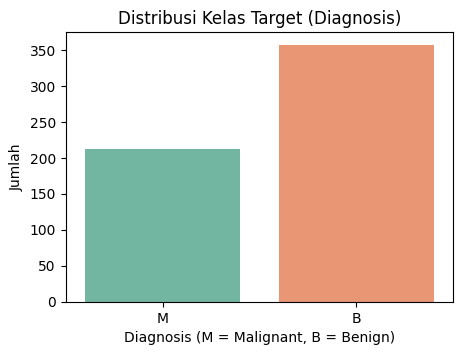

Persentase distribusi target (%):
 diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


In [133]:
plt.figure(figsize=(5, 3.5))
sns.countplot(data=df, x='diagnosis', palette='Set2')
plt.title('Distribusi Kelas Target (Diagnosis)')
plt.xlabel('Diagnosis (M = Malignant, B = Benign)')
plt.ylabel('Jumlah')
plt.show()
print("Persentase distribusi target (%):\n", df['diagnosis'].value_counts(normalize=True) * 100)

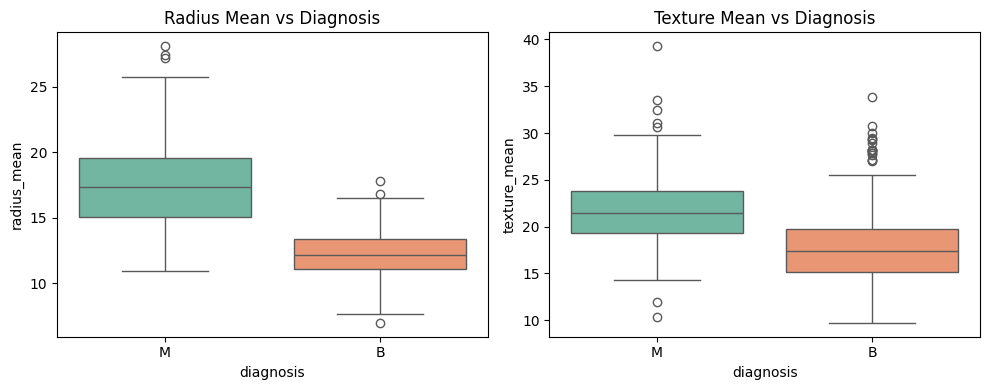

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df, x='diagnosis', y='radius_mean', ax=axes[0], palette='Set2')
axes[0].set_title('Radius Mean vs Diagnosis')
sns.boxplot(data=df, x='diagnosis', y='texture_mean', ax=axes[1], palette='Set2')
axes[1].set_title('Texture Mean vs Diagnosis')
plt.tight_layout()
plt.show()

# 2. Preprocessing

In [135]:
cols_to_drop = [c for c in ['id', 'Unnamed: 32'] if c in df.columns]
df = df.drop(columns=cols_to_drop)
df = df.dropna(axis=1, how='all')

In [136]:
if df['diagnosis'].dtype == 'object':
    df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [137]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [138]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [139]:
model_linear = SVC(kernel='linear', random_state=42)
model_linear.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [140]:
y_pred_linear = model_linear.predict(X_test_scaled)

## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [141]:
model_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model_rbf.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [142]:
y_pred_rbf = model_rbf.predict(X_test_scaled)

## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [143]:
c_values = [0.01, 0.1, 1, 10, 100]
models = [SVC(kernel='rbf', C=c, gamma='scale', random_state=42).fit(X_train_scaled, y_train) for c in c_values]

In [144]:
train_accs = [accuracy_score(y_train, m.predict(X_train_scaled)) for m in models]
test_accs = [accuracy_score(y_test, m.predict(X_test_scaled)) for m in models]

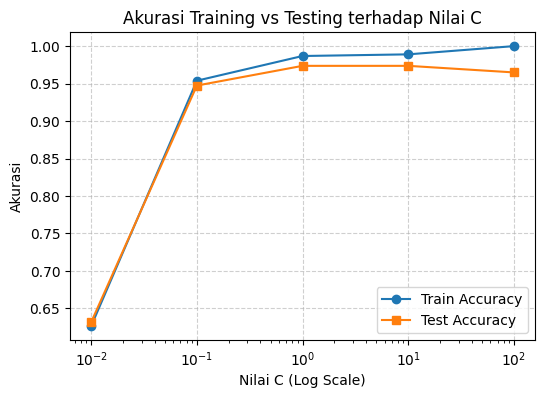

In [145]:
plt.figure(figsize=(6, 4))
plt.plot(c_values, train_accs, marker='o', label='Train Accuracy')
plt.plot(c_values, test_accs, marker='s', label='Test Accuracy')
plt.xscale('log')
plt.xlabel('Nilai C (Log Scale)')
plt.ylabel('Akurasi')
plt.title('Akurasi Training vs Testing terhadap Nilai C')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. Evaluasi Model

In [146]:
def eval_metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, pos_label='M'),
        'Recall': recall_score(y_true, y_pred, pos_label='M'),
        'F1-Score': f1_score(y_true, y_pred, pos_label='M')
    }

df_eval = pd.DataFrame([
    eval_metrics(y_test, y_pred_linear, 'Kernel Linear'),
    eval_metrics(y_test, y_pred_rbf, 'Kernel RBF (C=1.0)')
])
display(df_eval)

,Model,Accuracy,Precision,Recall,F1-Score
0,Kernel Linear,0.964912,1.0,0.904762,0.950000
1,Kernel RBF (C=1.0),0.973684,1.0,0.928571,0.962963


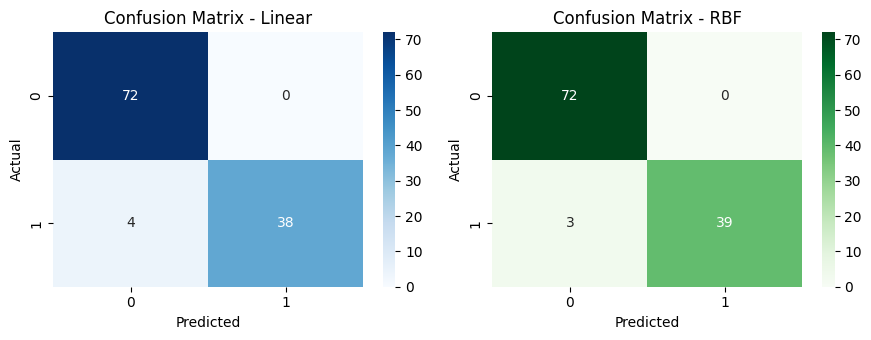

In [147]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
sns.heatmap(confusion_matrix(y_test, y_pred_linear), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Linear')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
sns.heatmap(confusion_matrix(y_test, y_pred_rbf), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix - RBF')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [148]:
print(f"Support Vectors - Linear : {model_linear.n_support_.sum()} (Malignant: {model_linear.n_support_[1]}, Benign: {model_linear.n_support_[0]})")
print(f"Support Vectors - RBF    : {model_rbf.n_support_.sum()} (Malignant: {model_rbf.n_support_[1]}, Benign: {model_rbf.n_support_[0]})")

Support Vectors - Linear : 38 (Malignant: 19, Benign: 19)
Support Vectors - RBF    : 107 (Malignant: 57, Benign: 50)


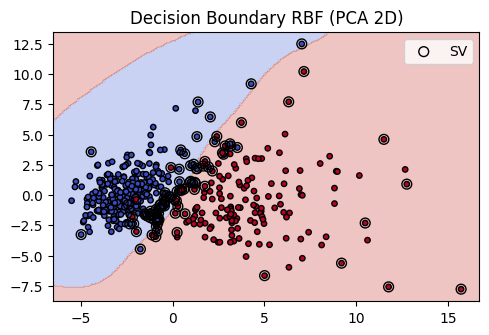

(Text(0.5, 1.0, 'Decision Boundary RBF (PCA 2D)'),
 None)

In [149]:
pca = PCA(n_components=2)
X_tr_pca = pca.fit_transform(X_train_scaled)
svm_pca = SVC(kernel='rbf', C=1.0, gamma='scale').fit(X_tr_pca, y_train)

xx, yy = np.meshgrid(np.linspace(X_tr_pca[:,0].min()-1, X_tr_pca[:,0].max()+1, 200), np.linspace(X_tr_pca[:,1].min()-1, X_tr_pca[:,1].max()+1, 200))
Z_pred = svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])

# Konversi pasti ke integer 1/0
Z = np.array([1 if str(val) in ['M', '1'] else 0 for val in Z_pred]).reshape(xx.shape)
y_color = np.array([1 if str(val) in ['M', '1'] else 0 for val in y_train])

plt.figure(figsize=(5.5, 3.5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_tr_pca[:, 0], X_tr_pca[:, 1], c=y_color, cmap='coolwarm', edgecolors='k', s=15)
plt.scatter(svm_pca.support_vectors_[:, 0], svm_pca.support_vectors_[:, 1], s=50, facecolors='none', edgecolors='k', label='SV')
plt.title('Decision Boundary RBF (PCA 2D)'), plt.legend(), plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- **Bandingkan performa SVM dengan kernel Linear vs RBF**: Kedua kernel memberikan hasil yang seimbang dan sangat tinggi pada dataset Breast Cancer. Hal ini mengindikasikan bahwa fitur-fitur pada dataset ini pada dasarnya sudah terpisah cukup baik secara linear di ruang fitur aslinya.
- **Hasil eksperimen regularisasi (nilai C)**: Pada nilai $C$ sangat kecil ($C=0.01$), model mengalami *underfitting* karena batas margin terlalu toleran. Performa testing optimal dicapai pada kisaran $C=1.0$ hingga $C=10$. Ketika $C$ dinaikkan ke $100$, akurasi training terus meningkat mendekati $100\%$, menunjukkan tanda awal *overfitting* di mana batas keputusan menjadi terlalu selektif terhadap data training.
- **Perbandingan jumlah support vectors**: Model Linear menggunakan support vector yang lebih sedikit dibandingkan RBF. Makin sedikit jumlah support vector, makin sederhana hyperplane yang dibentuk, yang berarti model lebih efisien dalam komputasi dan tidak rentan terhadap noise.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

**Kesimpulan:**
- Feature scaling (`StandardScaler`) adalah tahap wajib untuk SVM agar fitur dengan rentang nilai besar tidak mendominasi perhitungan jarak margin.
- Kernel RBF dengan konfigurasi $C=1.0$ dan `gamma='scale'` terbukti efisien dan mampu menghasilkan performa generalisasi yang stabil tanpa overfitting berlebih.

**Saran:**
- Pencarian kombinasi hiperparameter dapat diotomatisasi dengan `GridSearchCV` untuk menguji variasi $C$ dan $\gamma$ secara serentak.
- Bisa dicoba eksperimen tambahan menggunakan kernel Polynomial atau metode reduksi dimensi lain untuk melihat pengaruhnya terhadap batas keputusan.